# Baseline Age Model Training (LDAE, Improved)

Combined male+female baseline age model using pre-encoded LDAE labels with age-aware sample weighting and 3-stage fine-tuning for comparison against hierarchical models.


In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_DIR = Path("/content/data")
    CHECKPOINT_DIR = Path("/content/checkpoints/baseline_age_model_improved")
else:
    NOTEBOOK_DIR = Path(".").resolve()
    PROJECT_ROOT = NOTEBOOK_DIR.parent
    DATA_DIR = PROJECT_ROOT / "data"
    CHECKPOINT_DIR = PROJECT_ROOT / "models" / "baseline_age_model_improved"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_DIR = DATA_DIR / "utk_face"
TRAIN_AGE_MALE_CSV = DATA_DIR / "splits" / "train_age_male.csv"
TRAIN_AGE_FEMALE_CSV = DATA_DIR / "splits" / "train_age_female.csv"
VAL_AGE_MALE_CSV = DATA_DIR / "splits" / "val_age_male.csv"
VAL_AGE_FEMALE_CSV = DATA_DIR / "splits" / "val_age_female.csv"
TEST_CSV = DATA_DIR / "splits" / "test.csv"

BEST_MODEL = CHECKPOINT_DIR / "best_baseline_age_model_improved.keras"

print(f"Running in Colab: {IN_COLAB}")
print(f"Data dir        : {DATA_DIR}")
print(f"Images dir      : {IMAGES_DIR}")
print(f"Checkpoint dir  : {CHECKPOINT_DIR}")


Running in Colab: True
Data dir        : /content/data
Images dir      : /content/data/utk_face
Checkpoint dir  : /content/checkpoints/baseline_age_model_improved


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 15
EPOCHS_STAGE3 = 10
LR_STAGE1 = 1e-3
LR_STAGE2 = 1e-5
LR_STAGE3 = 5e-6
DROPOUT_RATE = 0.3
DENSE_UNITS = 256
NUM_AGE_BINS = 117
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)


TensorFlow version : 2.19.0
GPUs available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def parse_age_distribution(dist_str: str) -> np.ndarray:
    values = np.fromstring(dist_str, sep=",", dtype=np.float32)
    if values.size != NUM_AGE_BINS:
        raise ValueError(
            f"Expected {NUM_AGE_BINS} LDAE bins, got {values.size}."
        )

    total = float(values.sum())
    if total <= 0:
        raise ValueError("Invalid LDAE distribution with non-positive sum.")

    return values / total


def load_age_dataframe(
    csv_path: Path,
) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["filepath"] = df["filename"].apply(
        lambda fname: str(IMAGES_DIR / fname)
    )
    df["age_distribution_arr"] = df["age_distribution"].apply(
        parse_age_distribution
    )
    return df[["filepath", "age", "gender_id", "age_distribution_arr"]]


train_df = pd.concat([load_age_dataframe(TRAIN_AGE_MALE_CSV), load_age_dataframe(TRAIN_AGE_FEMALE_CSV)], ignore_index=True)
val_df = pd.concat([load_age_dataframe(VAL_AGE_MALE_CSV), load_age_dataframe(VAL_AGE_FEMALE_CSV)], ignore_index=True)

test_df = load_age_dataframe(TEST_CSV)
test_df = test_df.reset_index(drop=True)

print(f"Train samples: {len(train_df)}")
print(f"Val samples  : {len(val_df)}")
print(f"Test samples : {len(test_df)}")

train_age = train_df["age"].astype(int).to_numpy()
age_counts = np.bincount(train_age, minlength=NUM_AGE_BINS)
age_weights = np.zeros(NUM_AGE_BINS, dtype=np.float32)

nonzero = age_counts > 0
age_weights[nonzero] = 1.0 / np.sqrt(age_counts[nonzero].astype(np.float32))
age_weights[nonzero] /= age_weights[nonzero].mean()

train_df = train_df.copy()
train_df["sample_weight"] = train_df["age"].astype(int).map(
    lambda a: float(age_weights[a])
)

print(
    f"Sample-weight range: "
    f"{train_df['sample_weight'].min():.4f} to "
    f"{train_df['sample_weight'].max():.4f}"
)


Train samples: 14104
Val samples  : 6045
Test samples : 3556
Sample-weight range: 0.1444 to 5.2391


In [4]:
AUTOTUNE = tf.data.AUTOTUNE


def parse_image(
    filepath: tf.Tensor,
    dist: tf.Tensor,
    sw: tf.Tensor,
):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = preprocess_input(image)
    return image, dist, sw


def augment(
    image: tf.Tensor,
    dist: tf.Tensor,
    sw: tf.Tensor,
):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image, dist, sw


def make_dataset(
    df: pd.DataFrame,
    training: bool = False,
    use_weights: bool = False,
) -> tf.data.Dataset:
    filepaths = df["filepath"].to_numpy()
    dists = np.stack(df["age_distribution_arr"].to_numpy()).astype(np.float32)

    if use_weights:
        sample_weights = df["sample_weight"].to_numpy(dtype=np.float32)
    else:
        sample_weights = np.ones(len(df), dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, dists, sample_weights))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    if use_weights:
        ds = ds.map(
            lambda x, y, w: (x, y, w),
            num_parallel_calls=AUTOTUNE,
        )
    else:
        ds = ds.map(
            lambda x, y, w: (x, y),
            num_parallel_calls=AUTOTUNE,
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


val_df = val_df.copy()
val_df["sample_weight"] = 1.0

test_df = test_df.copy()
test_df["sample_weight"] = 1.0

train_ds = make_dataset(train_df, training=True, use_weights=True)
val_ds = make_dataset(val_df, training=False, use_weights=False)
test_ds = make_dataset(test_df, training=False, use_weights=False)

print("Datasets built successfully.")


Datasets built successfully.


In [5]:
class ExpectedAgeMAE(keras.metrics.Metric):
    def __init__(
        self,
        name: str = "expected_age_mae",
        **kwargs,
    ):
        super().__init__(name=name, **kwargs)
        self.total_abs_error = self.add_weight(
            name="total_abs_error",
            initializer="zeros",
        )
        self.count = self.add_weight(
            name="count",
            initializer="zeros",
        )
        self.age_bins = tf.cast(tf.range(NUM_AGE_BINS), tf.float32)

    def update_state(
        self,
        y_true,
        y_pred,
        sample_weight=None,
    ):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        true_age = tf.reduce_sum(y_true * self.age_bins, axis=-1)
        pred_age = tf.reduce_sum(y_pred * self.age_bins, axis=-1)
        abs_err = tf.abs(true_age - pred_age)

        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, tf.float32)
            abs_err = abs_err * sample_weight
            batch_count = tf.reduce_sum(sample_weight)
        else:
            batch_count = tf.cast(tf.size(abs_err), tf.float32)

        self.total_abs_error.assign_add(tf.reduce_sum(abs_err))
        self.count.assign_add(batch_count)

    def result(self):
        return tf.math.divide_no_nan(self.total_abs_error, self.count)

    def reset_state(self):
        self.total_abs_error.assign(0.0)
        self.count.assign(0.0)


def build_model(
    learning_rate: float,
    model_name: str,
) -> keras.Model:
    backbone = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMAGE_SIZE, 3),
        name="resnet50",
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="image_input")
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(DENSE_UNITS, activation="relu", name="fc1")(x)
    x = layers.Dropout(DROPOUT_RATE, name="dropout")(x)
    outputs = layers.Dense(
        NUM_AGE_BINS,
        activation="softmax",
        name="age_distribution_output",
    )(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.KLDivergence(),
        metrics=[ExpectedAgeMAE()],
    )
    return model


def freeze_backbone_except(
    backbone: keras.Model,
    trainable_prefixes: tuple[str, ...],
) -> None:
    backbone.trainable = True
    for layer in backbone.layers:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in trainable_prefixes
        )
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


def make_callbacks(
    stage_name: str,
    patience: int = 5,
):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(BEST_MODEL),
            monitor="val_expected_age_mae",
            mode="min",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_expected_age_mae",
            mode="min",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            str(CHECKPOINT_DIR / f"{stage_name}_history.csv"),
            append=False,
        ),
    ]


if BEST_MODEL.exists():
    model = keras.models.load_model(
        str(BEST_MODEL),
        custom_objects={"ExpectedAgeMAE": ExpectedAgeMAE},
    )
    print(f"Resumed from checkpoint: {BEST_MODEL}")
else:
    model = build_model(
        learning_rate=LR_STAGE1,
        model_name="baseline_age_model_improved",
    )
    print("No checkpoint found, starting from scratch.")

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
No checkpoint found, starting from scratch.


Model: "baseline_age_model_improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ age_distribution_output (Dense) │ (None, 117)            │        30,069 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,142,325 (92.10 MB)

 Trainable params: 554,613 (2.12 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
# Stage 1: train head with frozen backbone
if not BEST_MODEL.exists():
    model = build_model(
        learning_rate=LR_STAGE1,
        model_name="baseline_age_model_improved",
    )
else:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE1),
        loss=keras.losses.KLDivergence(),
        metrics=[ExpectedAgeMAE()],
    )

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=make_callbacks("stage1"),
)


Epoch 1/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - expected_age_mae: 13.0621 - loss: 0.6460
Epoch 1: val_expected_age_mae improved from inf to 7.48684, saving model to /content/checkpoints/baseline_age_model_improved/best_baseline_age_model_improved.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 89s 169ms/step - expected_age_mae: 13.0559 - loss: 0.6458 - val_expected_age_mae: 7.4868 - val_loss: 1.1436 - learning_rate: 0.0010
Epoch 2/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - expected_age_mae: 8.1648 - loss: 0.4769
Epoch 2: val_expected_age_mae improved from 7.48684 to 7.35343, saving model to /content/checkpoints/baseline_age_model_improved/best_baseline_age_model_improved.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 64s 146ms/step - expected_age_mae: 8.1646 - loss: 0.4769 - val_expected_age_mae: 7.3534 - val_loss: 1.0740 - learning_rate: 0.0010
Epoch 3/20
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - expected_age_mae: 7.5992 - loss: 0.4467
Epoch 3: val_expected_age_mae improved from 7.35343 to 7.0

In [7]:
# Stage 2: fine-tune conv5
model = keras.models.load_model(
    str(BEST_MODEL),
    custom_objects={"ExpectedAgeMAE": ExpectedAgeMAE},
)

backbone = model.get_layer("resnet50")
freeze_backbone_except(
    backbone,
    trainable_prefixes=("conv5",),
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE2),
    loss=keras.losses.KLDivergence(),
    metrics=[ExpectedAgeMAE()],
)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=make_callbacks("stage2"),
)


Epoch 1/15
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - expected_age_mae: 6.3209 - loss: 0.3619
Epoch 1: val_expected_age_mae improved from inf to 6.94645, saving model to /content/checkpoints/baseline_age_model_improved/best_baseline_age_model_improved.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 110s 211ms/step - expected_age_mae: 6.3209 - loss: 0.3619 - val_expected_age_mae: 6.9464 - val_loss: 1.0202 - learning_rate: 1.0000e-05
Epoch 2/15
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - expected_age_mae: 5.7441 - loss: 0.3353
Epoch 2: val_expected_age_mae improved from 6.94645 to 6.62264, saving model to /content/checkpoints/baseline_age_model_improved/best_baseline_age_model_improved.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 81s 183ms/step - expected_age_mae: 5.7441 - loss: 0.3353 - val_expected_age_mae: 6.6226 - val_loss: 0.9949 - learning_rate: 1.0000e-05
Epoch 3/15
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - expected_age_mae: 5.3131 - loss: 0.3100
Epoch 3: val_expected_age_mae improved from 6.62264

In [8]:
# Stage 3: fine-tune conv4 + conv5
model = keras.models.load_model(
    str(BEST_MODEL),
    custom_objects={"ExpectedAgeMAE": ExpectedAgeMAE},
)

backbone = model.get_layer("resnet50")
freeze_backbone_except(
    backbone,
    trainable_prefixes=("conv4", "conv5"),
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE3),
    loss=keras.losses.KLDivergence(),
    metrics=[ExpectedAgeMAE()],
)

history_stage3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE3,
    callbacks=make_callbacks("stage3"),
)

print(f"Training complete. Best model saved to: {BEST_MODEL}")


Epoch 1/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - expected_age_mae: 3.6479 - loss: 0.2116
Epoch 1: val_expected_age_mae improved from inf to 6.27384, saving model to /content/checkpoints/baseline_age_model_improved/best_baseline_age_model_improved.keras
441/441 ━━━━━━━━━━━━━━━━━━━━ 145s 279ms/step - expected_age_mae: 3.6481 - loss: 0.2116 - val_expected_age_mae: 6.2738 - val_loss: 1.0451 - learning_rate: 5.0000e-06
Epoch 2/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - expected_age_mae: 3.5895 - loss: 0.2041
Epoch 2: val_expected_age_mae did not improve from 6.27384
441/441 ━━━━━━━━━━━━━━━━━━━━ 107s 241ms/step - expected_age_mae: 3.5895 - loss: 0.2041 - val_expected_age_mae: 6.3795 - val_loss: 1.0763 - learning_rate: 5.0000e-06
Epoch 3/10
441/441 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - expected_age_mae: 3.4978 - loss: 0.2014
Epoch 3: val_expected_age_mae did not improve from 6.27384
441/441 ━━━━━━━━━━━━━━━━━━━━ 106s 241ms/step - expected_age_mae: 3.4977 - loss: 0.2014 - val_expecte

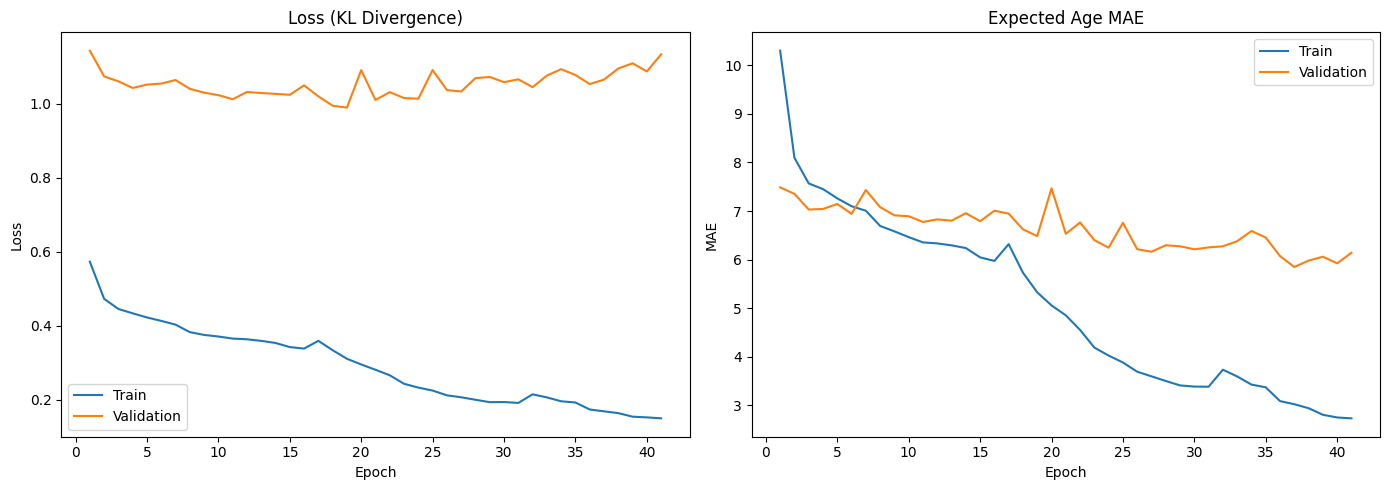

In [9]:
def _concat_metric(
    histories,
    key: str,
):
    values = []
    for h in histories:
        values.extend(h.history.get(key, []))
    return values


all_histories = [history_stage1, history_stage2, history_stage3]
train_loss = _concat_metric(all_histories, "loss")
val_loss = _concat_metric(all_histories, "val_loss")
train_mae = _concat_metric(all_histories, "expected_age_mae")
val_mae = _concat_metric(all_histories, "val_expected_age_mae")

epoch_axis = np.arange(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epoch_axis, train_loss, label="Train")
axes[0].plot(epoch_axis, val_loss, label="Validation")
axes[0].set_title("Loss (KL Divergence)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epoch_axis, train_mae, label="Train")
axes[1].plot(epoch_axis, val_mae, label="Validation")
axes[1].set_title("Expected Age MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()


In [10]:
best_model = keras.models.load_model(
    str(BEST_MODEL),
    custom_objects={"ExpectedAgeMAE": ExpectedAgeMAE},
)

eval_metrics = best_model.evaluate(test_ds, verbose=1)
print("\nTest metrics:")
for name, value in zip(best_model.metrics_names, eval_metrics):
    print(f"{name}: {value:.6f}")

age_bins = np.arange(NUM_AGE_BINS, dtype=np.float32)
pred_dist = best_model.predict(test_ds, verbose=1)
pred_age = (pred_dist * age_bins[None, :]).sum(axis=1)
true_age = test_df["age"].to_numpy(dtype=np.float32)
manual_mae = np.mean(np.abs(pred_age - true_age))
print(f"Manual decoded-age MAE: {manual_mae:.4f}")


112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 123ms/step - expected_age_mae: 5.8244 - loss: 1.0575

Test metrics:
loss: 1.064664
compile_metrics: 5.780881
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step
Manual decoded-age MAE: 5.7906


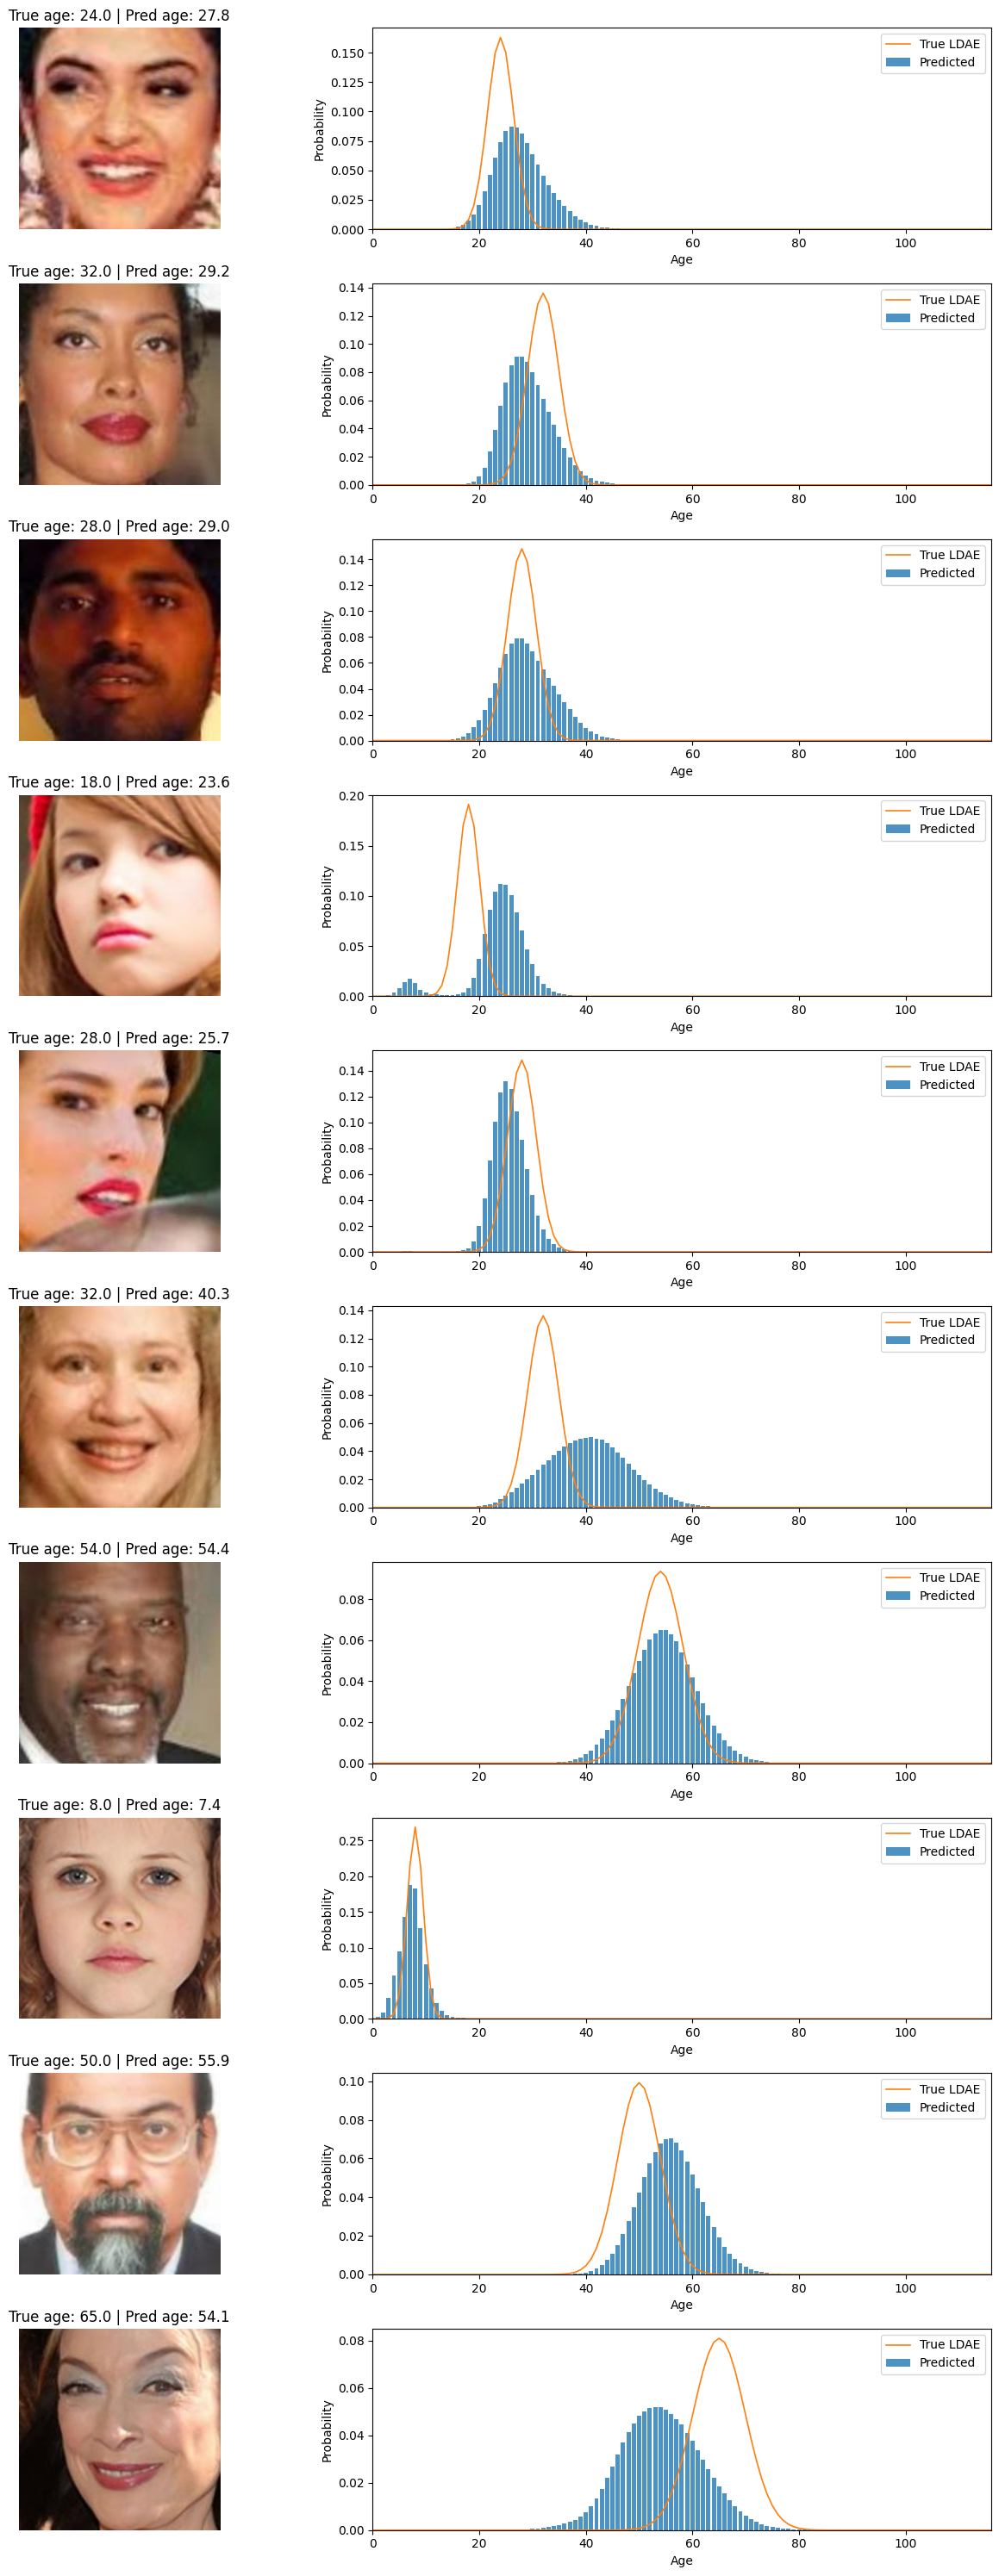

In [11]:
def load_display_image(
    filepath: str,
) -> np.ndarray:
    img = PILImage.open(filepath).convert("RGB").resize(IMAGE_SIZE)
    return np.array(img)


def preprocess_for_model(
    filepath: str,
) -> np.ndarray:
    img = load_display_image(filepath).astype(np.float32)
    img = preprocess_input(img)
    return img


def show_sample_predictions(
    model: keras.Model,
    df: pd.DataFrame,
    n_samples: int = 10,
    seed: int = 42,
) -> None:
    if len(df) < n_samples:
        n_samples = len(df)

    sample_df = df.sample(n=n_samples, random_state=seed).reset_index(drop=True)
    age_bins = np.arange(NUM_AGE_BINS)

    fig, axes = plt.subplots(n_samples, 2, figsize=(14, 3 * n_samples))
    if n_samples == 1:
        axes = np.array([axes])

    for i in range(n_samples):
        path = sample_df.loc[i, "filepath"]
        true_age = float(sample_df.loc[i, "age"])
        true_dist = np.array(sample_df.loc[i, "age_distribution_arr"], dtype=np.float32)

        x = preprocess_for_model(path)
        pred = model.predict(np.expand_dims(x, axis=0), verbose=0)[0]
        pred_age = float(np.sum(pred * age_bins))

        ax_img = axes[i, 0]
        ax_bar = axes[i, 1]

        ax_img.imshow(load_display_image(path))
        ax_img.axis("off")
        ax_img.set_title(f"True age: {true_age:.1f} | Pred age: {pred_age:.1f}")

        ax_bar.bar(
            age_bins,
            pred,
            alpha=0.8,
            label="Predicted",
            color="#1f77b4",
        )
        ax_bar.plot(
            age_bins,
            true_dist,
            label="True LDAE",
            color="#ff7f0e",
            linewidth=1.2,
        )
        ax_bar.set_xlim(0, NUM_AGE_BINS - 1)
        ax_bar.set_xlabel("Age")
        ax_bar.set_ylabel("Probability")
        ax_bar.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


show_sample_predictions(
    best_model,
    test_df,
    n_samples=10,
    seed=SEED,
)
